In [1]:
# --- Imports & style ---
import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme(style="whitegrid", palette="rocket")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


ModuleNotFoundError: No module named 'requests'

In [ ]:
TOPICS = ["Menstrual health", "Sexual health", "Healthy ageing",
          "Postpartum", "Mental health"]

# Real WHO GHO indicator codes. Menstrual health has none -
# see Section 2 for why, and what to do about it instead.
# Full catalog: https://ghoapi.azureedge.net/api/Indicator
INDICATORS = {
    "fpsmo":           ("Sexual health",  "Demand for family planning satisfied - modern methods (%)"),
    "MDG_0000000015":  ("Sexual health",  "Condom use at higher-risk sex, adults 15-49 (%)"),
    "WHOSIS_000002":   ("Healthy ageing", "Healthy life expectancy (HALE) at birth (years)"),
    "MDG_0000000026":  ("Postpartum",     "Maternal mortality ratio (per 100,000 live births)"),
    "anc4":            ("Postpartum",     "Antenatal care coverage - at least 4 visits (%)"),
    "csection":        ("Postpartum",     "Births by caesarean section (%)"),
    "MH_12":           ("Mental health",  "Age-standardized suicide rate (per 100,000)"),
}

country_names = pd.read_csv("/kaggle/input/datasets/britneykibaara/who-african-countries/who_afr_countries (1).csv")
AFR_ISO3 = set(country_names["iso3"])
BASE_URL = "https://ghoapi.azureedge.net/api/"
RAW_DATA_PATH = "who_mvp_topic_data.csv"


In [ ]:
def fetch_indicator(code, timeout=60):
    url = f"{BASE_URL}{code}?$filter=SpatialDimType eq \'COUNTRY\'"
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()
    return resp.json().get("value", [])


def fetch_all(indicators):
    rows = []
    for code, (topic, label) in indicators.items():
        print(f"Fetching {code} ({topic}: {label})...")
        try:
            records = fetch_indicator(code)
        except Exception as e:
            print(f"  FAILED: {e} - skipping, rerun this cell to retry just this indicator")
            continue
        for r in records:
            if r.get("SpatialDim") not in AFR_ISO3:
                continue
            rows.append({
                "mvp_topic": topic,
                "indicator": code,
                "indicator_label": label,
                "country_iso3": r.get("SpatialDim"),
                "sex": r.get("Dim1"),          # e.g. SEX_FMLE / SEX_MLE / SEX_BTSX, where available
                "year": r.get("TimeDim"),
                "value": r.get("NumericValue"),
            })
    return pd.DataFrame(rows)


if os.path.exists(RAW_DATA_PATH):
    print(f"Found cached {RAW_DATA_PATH} - loading it. Delete the file and re-run to force a fresh fetch.")
    raw_df = pd.read_csv(RAW_DATA_PATH)
else:
    raw_df = fetch_all(INDICATORS)
    raw_df = raw_df.merge(country_names, left_on="country_iso3", right_on="iso3", how="left")
    raw_df = raw_df.drop(columns=["iso3"]).rename(columns={"country": "country"})
    raw_df.to_csv(RAW_DATA_PATH, index=False)
    print(f"Saved {len(raw_df)} rows to {RAW_DATA_PATH}")

raw_df.head()


Fetching fpsmo (Sexual health: Demand for family planning satisfied - modern methods (%))...
Fetching MDG_0000000015 (Sexual health: Condom use at higher-risk sex, adults 15-49 (%))...
Fetching WHOSIS_000002 (Healthy ageing: Healthy life expectancy (HALE) at birth (years))...
Fetching MDG_0000000026 (Postpartum: Maternal mortality ratio (per 100,000 live births))...
Fetching anc4 (Postpartum: Antenatal care coverage - at least 4 visits (%))...
Fetching csection (Postpartum: Births by caesarean section (%))...
Fetching MH_12 (Mental health: Age-standardized suicide rate (per 100,000))...
Saved 9441 rows to who_mvp_topic_data.csv


,mvp_topic,indicator,indicator_label,country_iso3,sex,year,value,country,who_region
0,Sexual health,MDG_0000000015,"Condom use at higher-risk sex, adults 15-49 (%)",ETH,SEX_FMLE,2013,47.0,Ethiopia,AFR
1,Sexual health,MDG_0000000015,"Condom use at higher-risk sex, adults 15-49 (%)",COM,SEX_FMLE,2013,15.0,Comoros,AFR
2,Sexual health,MDG_0000000015,"Condom use at higher-risk sex, adults 15-49 (%)",CMR,SEX_MLE,2013,43.0,Cameroon,AFR
3,Sexual health,MDG_0000000015,"Condom use at higher-risk sex, adults 15-49 (%)",MLI,SEX_MLE,2013,10.0,Mali,AFR
4,Sexual health,MDG_0000000015,"Condom use at higher-risk sex, adults 15-49 (%)",SLE,SEX_FMLE,2013,5.0,Sierra Leone,AFR


=== Postpartum ===
Rows: 2067 | Countries: 53 | Indicators: 1 | Years: 1985-2023


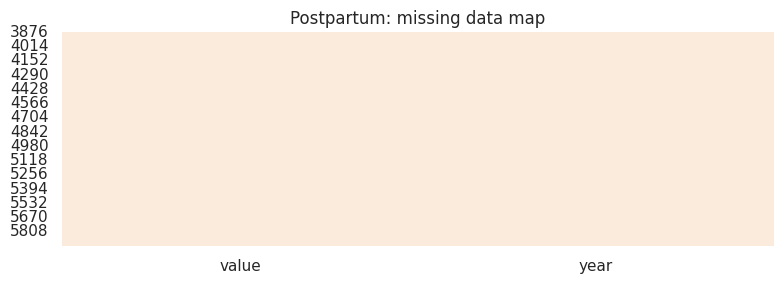

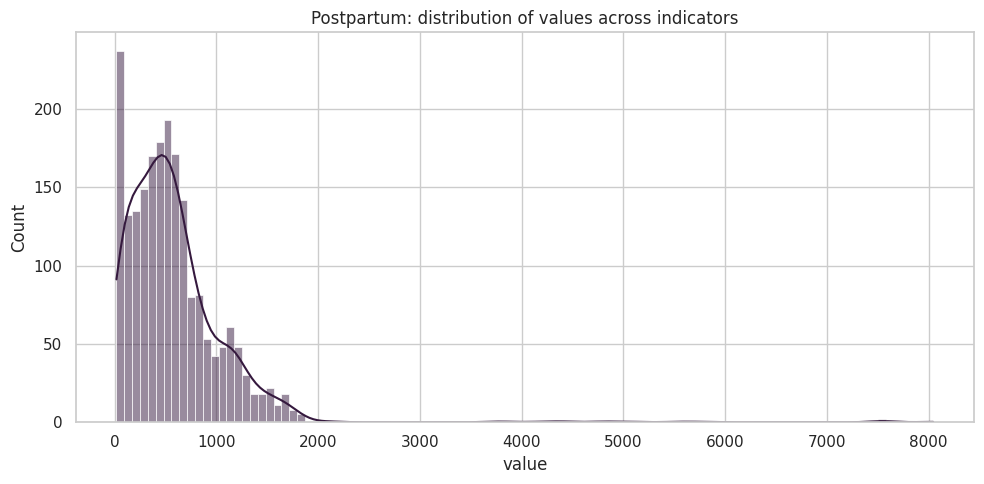

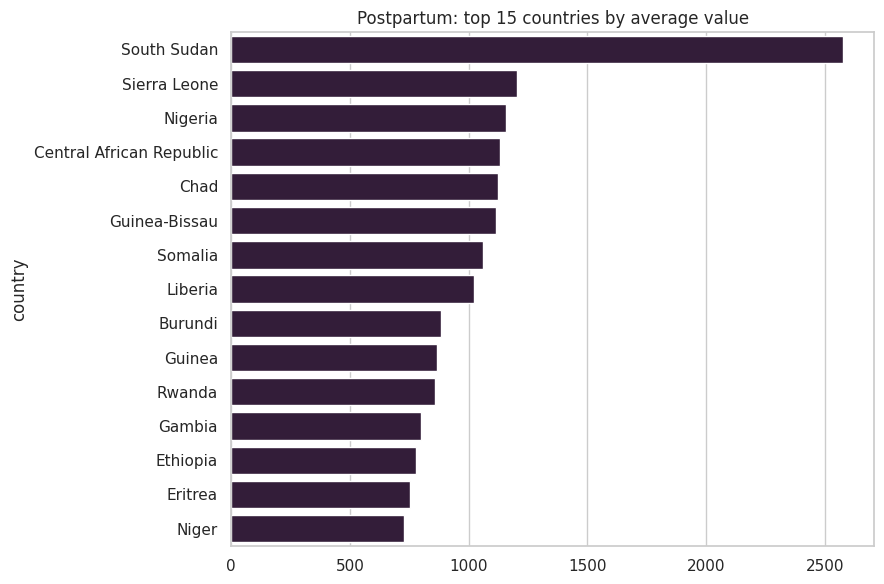

In [ ]:
def profile_topic(df, topic):
    sub = df[df["mvp_topic"] == topic]
    print(f"=== {topic} ===")
    if len(sub):
        print(f"Rows: {len(sub)} | Countries: {sub['country'].nunique()} | "
              f"Indicators: {sub['indicator'].nunique()} | "
              f"Years: {sub['year'].min()}-{sub['year'].max()}")
    else:
        print("No data")

    if sub.empty:
        return sub

    plt.figure(figsize=(8, 3))
    sns.heatmap(sub[["value", "year"]].isna(), cbar=False, cmap="rocket_r")
    plt.title(f"{topic}: missing data map")
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(sub["value"].dropna(), kde=True)
    plt.title(f"{topic}: distribution of values across indicators")
    plt.tight_layout()
    plt.show()

    top_countries = (
        sub.groupby("country")["value"].mean()
        .sort_values(ascending=False).head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title(f"{topic}: top 15 countries by average value")
    plt.tight_layout()
    plt.show()

    return sub


topic = "Postpartum"   # change to any topic with data: Sexual health / Healthy ageing / Postpartum / Mental health
_ = profile_topic(raw_df, topic)


=== Sexual health ===
Rows: 60 | Countries: 30 | Indicators: 1 | Years: 2013-2013


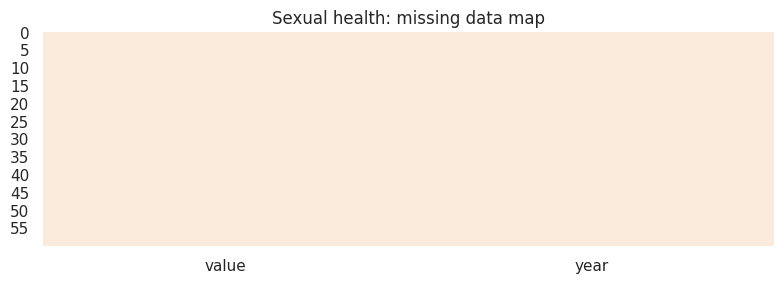

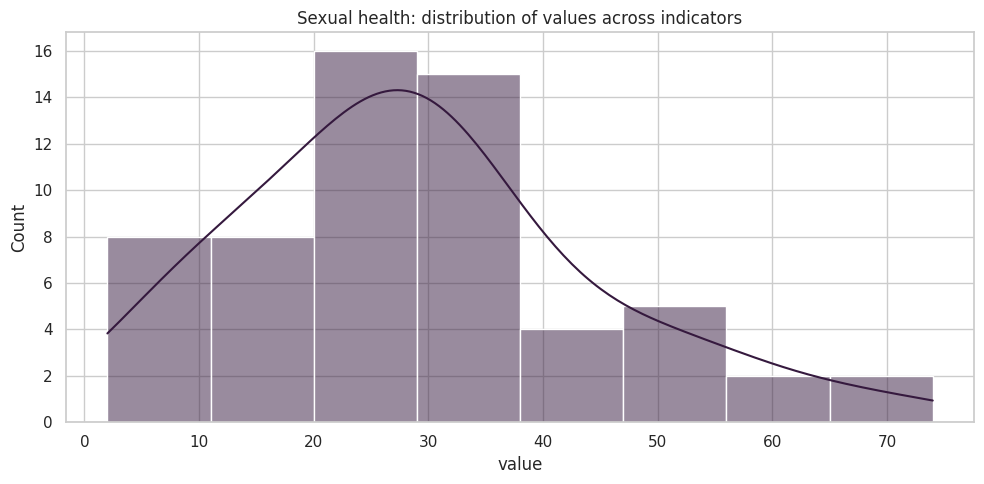

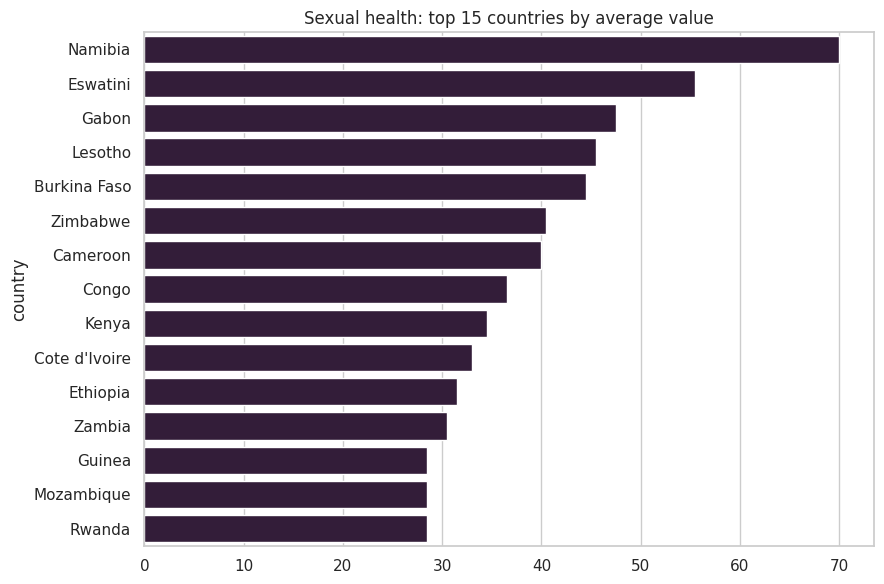

In [ ]:
def profile_topic(df, topic):
    sub = df[df["mvp_topic"] == topic]
    print(f"=== {topic} ===")
    if len(sub):
        print(f"Rows: {len(sub)} | Countries: {sub['country'].nunique()} | "
              f"Indicators: {sub['indicator'].nunique()} | "
              f"Years: {sub['year'].min()}-{sub['year'].max()}")
    else:
        print("No data")

    if sub.empty:
        return sub

    plt.figure(figsize=(8, 3))
    sns.heatmap(sub[["value", "year"]].isna(), cbar=False, cmap="rocket_r")
    plt.title(f"{topic}: missing data map")
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(sub["value"].dropna(), kde=True)
    plt.title(f"{topic}: distribution of values across indicators")
    plt.tight_layout()
    plt.show()

    top_countries = (
        sub.groupby("country")["value"].mean()
        .sort_values(ascending=False).head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title(f"{topic}: top 15 countries by average value")
    plt.tight_layout()
    plt.show()

    return sub


topic = "Sexual health"   # change to any topic with data: Sexual health / Healthy ageing / Postpartum / Mental health
_ = profile_topic(raw_df, topic)


=== Healthy ageing ===
Rows: 3816 | Countries: 53 | Indicators: 1 | Years: 2000-2023


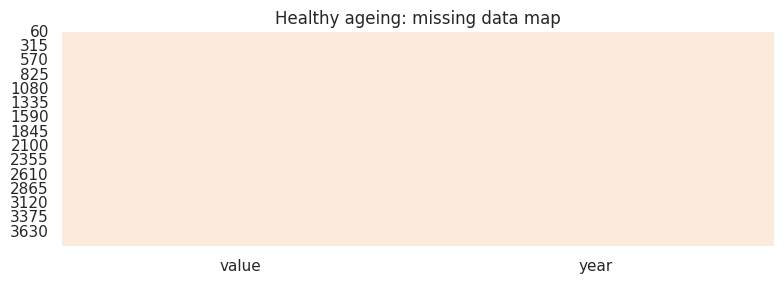

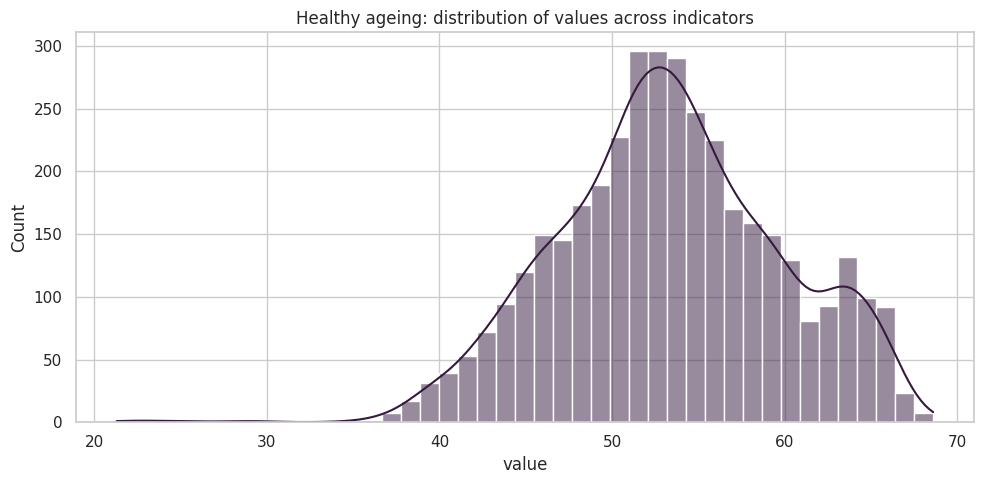

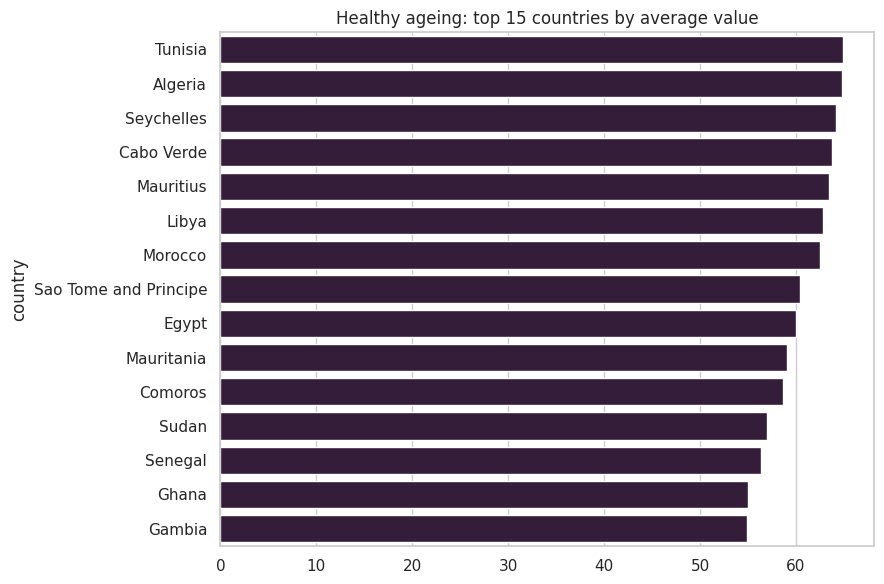

In [ ]:
def profile_topic(df, topic):
    sub = df[df["mvp_topic"] == topic]
    print(f"=== {topic} ===")
    if len(sub):
        print(f"Rows: {len(sub)} | Countries: {sub['country'].nunique()} | "
              f"Indicators: {sub['indicator'].nunique()} | "
              f"Years: {sub['year'].min()}-{sub['year'].max()}")
    else:
        print("No data")

    if sub.empty:
        return sub

    plt.figure(figsize=(8, 3))
    sns.heatmap(sub[["value", "year"]].isna(), cbar=False, cmap="rocket_r")
    plt.title(f"{topic}: missing data map")
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(sub["value"].dropna(), kde=True)
    plt.title(f"{topic}: distribution of values across indicators")
    plt.tight_layout()
    plt.show()

    top_countries = (
        sub.groupby("country")["value"].mean()
        .sort_values(ascending=False).head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title(f"{topic}: top 15 countries by average value")
    plt.tight_layout()
    plt.show()

    return sub


topic = "Healthy ageing"   # change to any topic with data: Sexual health / Healthy ageing / Postpartum / Mental health
_ = profile_topic(raw_df, topic)


=== Mental health ===
Rows: 3498 | Countries: 53 | Indicators: 1 | Years: 2000-2021


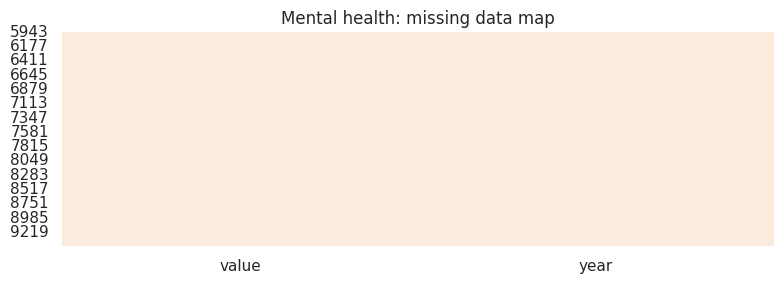

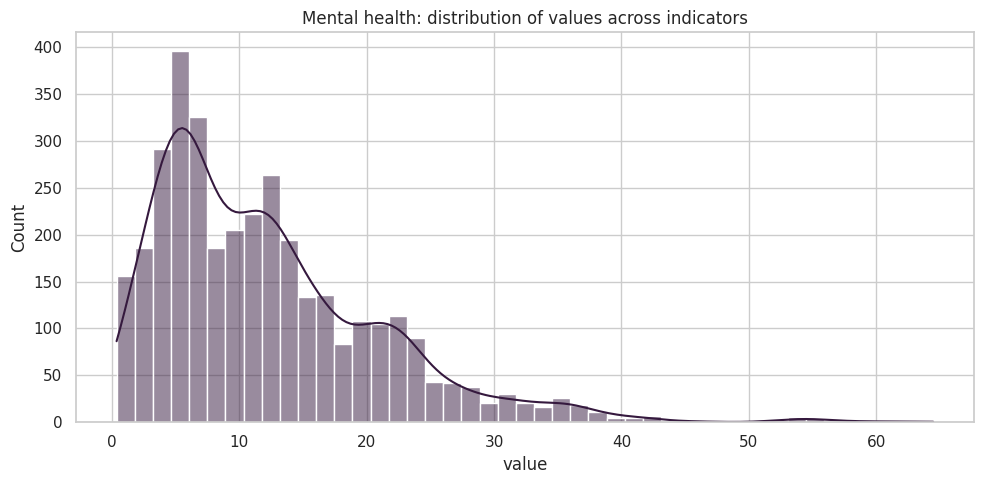

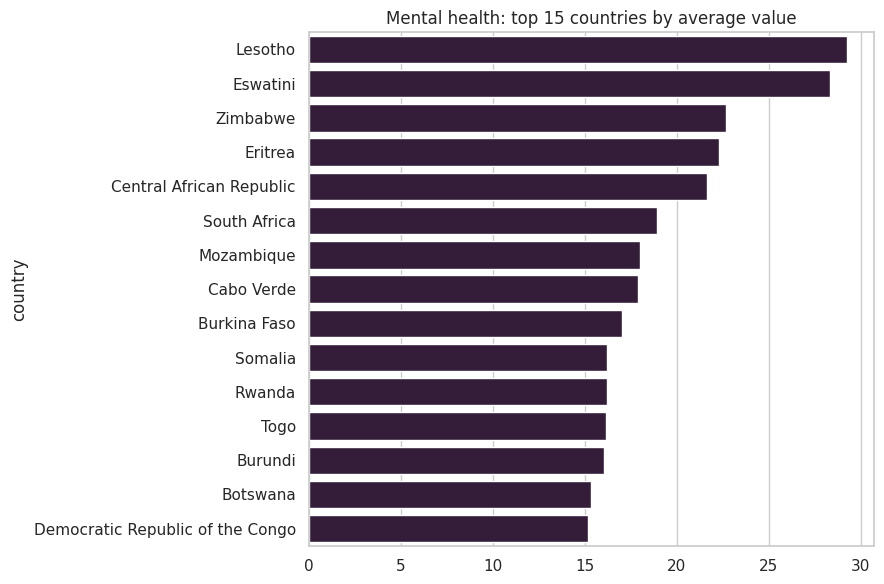

In [ ]:
def profile_topic(df, topic):
    sub = df[df["mvp_topic"] == topic]
    print(f"=== {topic} ===")
    if len(sub):
        print(f"Rows: {len(sub)} | Countries: {sub['country'].nunique()} | "
              f"Indicators: {sub['indicator'].nunique()} | "
              f"Years: {sub['year'].min()}-{sub['year'].max()}")
    else:
        print("No data")

    if sub.empty:
        return sub

    plt.figure(figsize=(8, 3))
    sns.heatmap(sub[["value", "year"]].isna(), cbar=False, cmap="rocket_r")
    plt.title(f"{topic}: missing data map")
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(sub["value"].dropna(), kde=True)
    plt.title(f"{topic}: distribution of values across indicators")
    plt.tight_layout()
    plt.show()

    top_countries = (
        sub.groupby("country")["value"].mean()
        .sort_values(ascending=False).head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title(f"{topic}: top 15 countries by average value")
    plt.tight_layout()
    plt.show()

    return sub


topic = "Mental health"   # change to any topic with data: Sexual health / Healthy ageing / Postpartum / Mental health
_ = profile_topic(raw_df, topic)


In [ ]:
MENSTRUAL_PROXY_PATH = "/kaggle/input/datasets/britneykibaara/menstrual-health/menstrual_health_ovulatory_knowledge.csv"

if os.path.exists(MENSTRUAL_PROXY_PATH):
    mh = pd.read_csv(MENSTRUAL_PROXY_PATH)
    mh = mh.merge(country_names, on="country", how="left")
    mh["indicator_label"] = "Ovulatory cycle knowledge, % correct, women 15-24 (proxy)"
    mh["sex"] = "SEX_FMLE"
    mh = mh[["mvp_topic", "indicator", "indicator_label", "iso3", "sex", "year", "value", "country"]]
    mh = mh.rename(columns={"iso3": "country_iso3"})

    raw_df = pd.concat([raw_df, mh], ignore_index=True, sort=False)
    print(f"Folded in {len(mh)} menstrual health rows (proxy dataset). raw_df now has {len(raw_df)} total rows.")
else:
    print(f"WARNING: {MENSTRUAL_PROXY_PATH} not found - menstrual health will show as having no data.")

raw_df[raw_df["mvp_topic"] == "Menstrual health"].head()


Folded in 29 menstrual health rows (proxy dataset). raw_df now has 9470 total rows.


,mvp_topic,indicator,indicator_label,country_iso3,sex,year,value,country,who_region
9441,Menstrual health,ovulatory_cycle_knowledge_pct,"Ovulatory cycle knowledge, % correct, women 15...",NGA,SEX_FMLE,2013,20.3,Nigeria,NaN
9442,Menstrual health,ovulatory_cycle_knowledge_pct,"Ovulatory cycle knowledge, % correct, women 15...",RWA,SEX_FMLE,2014,21.0,Rwanda,NaN
9443,Menstrual health,ovulatory_cycle_knowledge_pct,"Ovulatory cycle knowledge, % correct, women 15...",GHA,SEX_FMLE,2008,34.0,Ghana,NaN
9444,Menstrual health,ovulatory_cycle_knowledge_pct,"Ovulatory cycle knowledge, % correct, women 15...",ZWE,SEX_FMLE,2010,15.2,Zimbabwe,NaN
9445,Menstrual health,ovulatory_cycle_knowledge_pct,"Ovulatory cycle knowledge, % correct, women 15...",MWI,SEX_FMLE,2015,17.1,Malawi,NaN


=== Menstrual health ===
Rows: 29 | Countries: 29 | Indicators: 1 | Years: 2008-2016


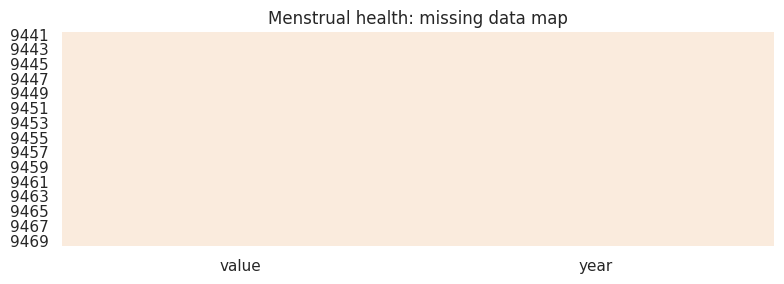

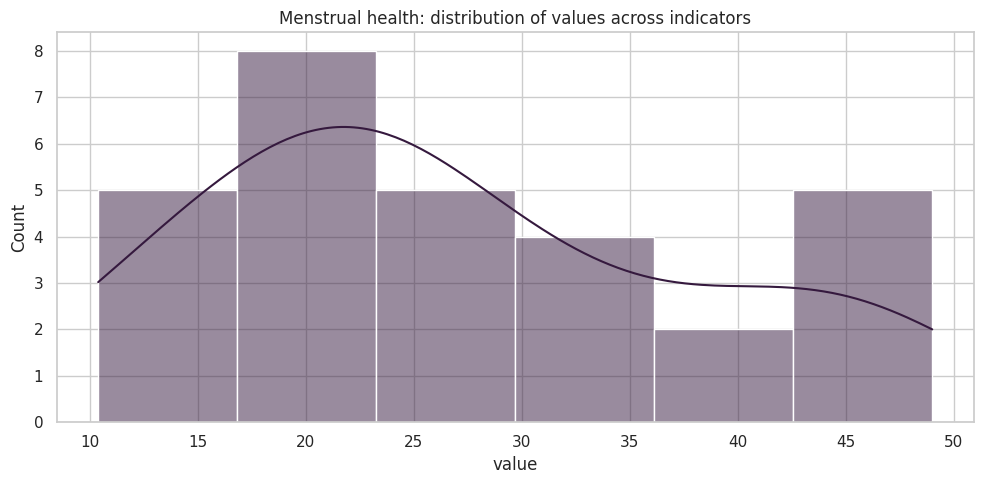

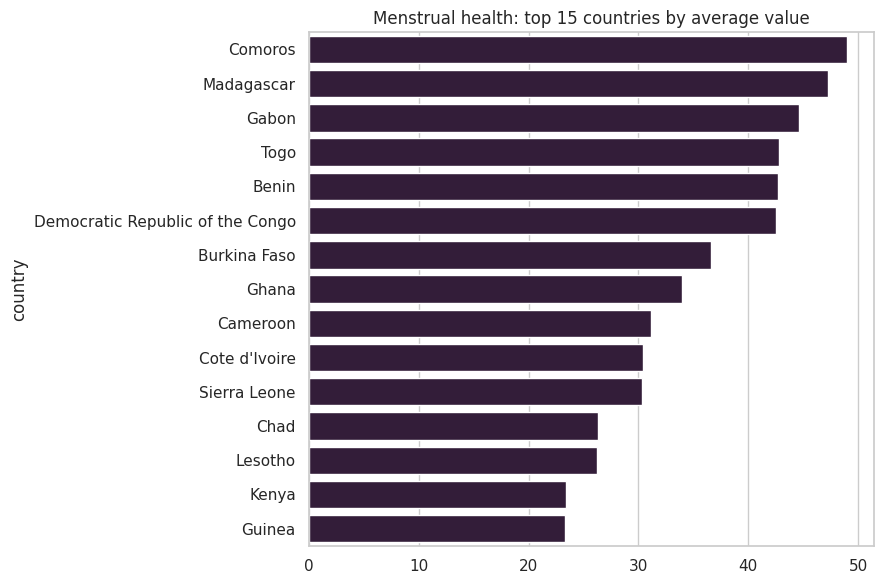

In [ ]:
def profile_topic(df, topic):
    sub = df[df["mvp_topic"] == topic]
    print(f"=== {topic} ===")
    if len(sub):
        print(f"Rows: {len(sub)} | Countries: {sub['country'].nunique()} | "
              f"Indicators: {sub['indicator'].nunique()} | "
              f"Years: {sub['year'].min()}-{sub['year'].max()}")
    else:
        print("No data")

    if sub.empty:
        return sub

    plt.figure(figsize=(8, 3))
    sns.heatmap(sub[["value", "year"]].isna(), cbar=False, cmap="rocket_r")
    plt.title(f"{topic}: missing data map")
    plt.tight_layout()
    plt.show()

    plt.figure()
    sns.histplot(sub["value"].dropna(), kde=True)
    plt.title(f"{topic}: distribution of values across indicators")
    plt.tight_layout()
    plt.show()

    top_countries = (
        sub.groupby("country")["value"].mean()
        .sort_values(ascending=False).head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index)
    plt.title(f"{topic}: top 15 countries by average value")
    plt.tight_layout()
    plt.show()

    return sub


topic = "Menstrual health"   # change to any topic with data: Sexual health / Healthy ageing / Postpartum / Mental health
_ = profile_topic(raw_df, topic)


## Sex disaggregated view

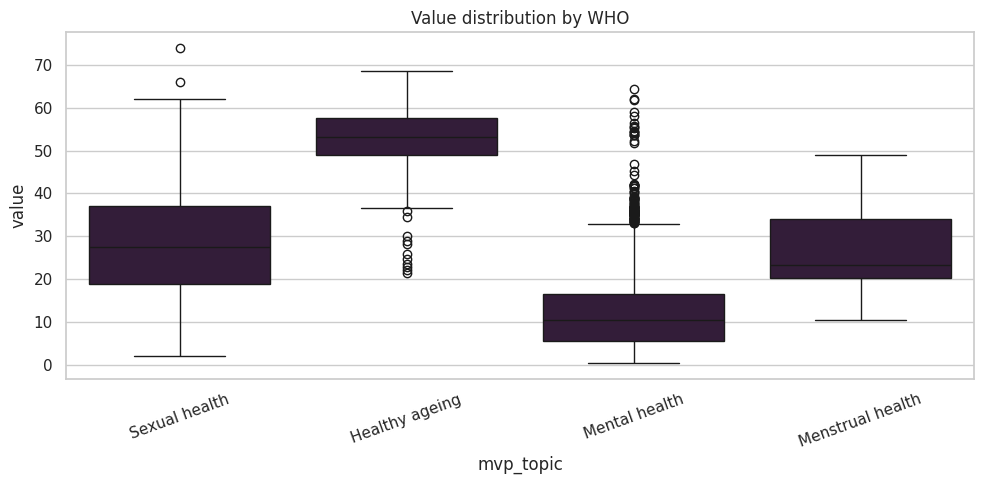

In [ ]:
sex_available = raw_df[raw_df["sex"].notna()]
if not sex_available.empty:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=sex_available, x="mvp_topic", y="value")
    plt.title("Value distribution by WHO")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("No sex-disaggregated rows in this fetch.")


## Cross topic knowledge gap summary

/tmp/ipykernel_58/2509587745.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=topic_summary, x="coverage_pct", y="mvp_topic", palette=colors)


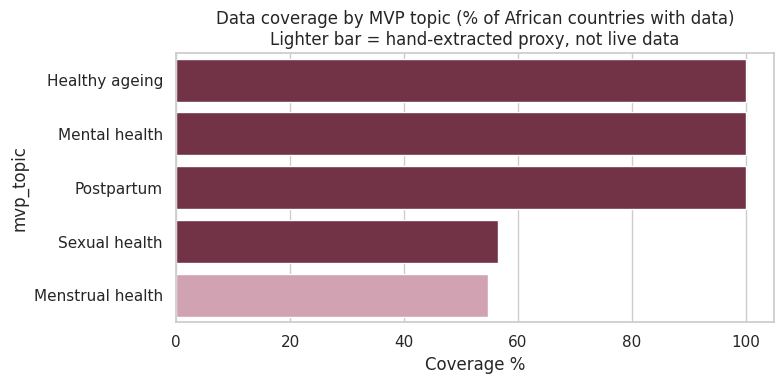

,mvp_topic,countries_covered,total_countries,coverage_pct,records,data_source,is_proxy
2,Healthy ageing,53,53,100.0,3816,WHO GHO (live API),False
4,Mental health,53,53,100.0,3498,WHO GHO (live API),False
3,Postpartum,53,53,100.0,2067,WHO GHO (live API),False
1,Sexual health,30,53,56.6,60,WHO GHO (live API),False
0,Menstrual health,29,53,54.7,29,"Iyanda et al. 2020 (hand-extracted proxy, ages...",True


In [ ]:
TOTAL_COUNTRIES = len(AFR_ISO3)
summary_rows = []

DATA_SOURCE = {
    "Menstrual health": "Iyanda et al. 2020 (hand-extracted proxy, ages 15-24 only, static)",
    "Sexual health": "WHO GHO (live API)",
    "Healthy ageing": "WHO GHO (live API)",
    "Postpartum": "WHO GHO (live API)",
    "Mental health": "WHO GHO (live API)",
}

for t in TOPICS:
    sub = raw_df[raw_df["mvp_topic"] == t]
    covered = sub["country"].nunique()
    summary_rows.append({
        "mvp_topic": t,
        "countries_covered": covered,
        "total_countries": TOTAL_COUNTRIES,
        "coverage_pct": round(covered / TOTAL_COUNTRIES * 100, 1) if TOTAL_COUNTRIES else 0,
        "records": len(sub),
        "data_source": DATA_SOURCE.get(t, "unknown"),
        "is_proxy": t == "Menstrual health",
    })

topic_summary = pd.DataFrame(summary_rows).sort_values("coverage_pct", ascending=False)
topic_summary.to_csv("topic_coverage_summary.csv", index=False)

plt.figure(figsize=(8, 4))
colors = ["#d99aae" if p else "#7c2942" for p in topic_summary["is_proxy"]]
sns.barplot(data=topic_summary, x="coverage_pct", y="mvp_topic", palette=colors)
plt.title("Data coverage by MVP topic (% of African countries with data)\nLighter bar = hand-extracted proxy, not live data")
plt.xlabel("Coverage %")
plt.tight_layout()
plt.show()

topic_summary


## Per topic/country detail (heatmap)

In [ ]:
detail_rows = []
for t in TOPICS:
    sub = raw_df[raw_df["mvp_topic"] == t]
    covered_countries = set(sub["country"].dropna().unique())
    for c in country_names["country"]:
        n = len(sub[sub["country"] == c])
        level = 2 if n >= 3 else (1 if n >= 1 else 0)
        detail_rows.append({"mvp_topic": t, "country": c, "records": n, "level": level})

topic_country_detail = pd.DataFrame(detail_rows)
topic_country_detail.to_csv("topic_country_detail.csv", index=False)
print(f"Saved {len(topic_country_detail)} topic x country rows to topic_country_detail.csv")
topic_country_detail.head()


Saved 265 topic x country rows to topic_country_detail.csv


,mvp_topic,country,records,level
0,Menstrual health,Algeria,0,0
1,Menstrual health,Angola,1,1
2,Menstrual health,Benin,1,1
3,Menstrual health,Botswana,0,0
4,Menstrual health,Burkina Faso,1,1


In [ ]:
topic_country_detail.to_csv("/kaggle/working/topic_country_detail.csv", index=False)

print("Saved!")
print(topic_country_detail.shape)

Saved!
(265, 4)


In [ ]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'topic_coverage_summary.csv', 'who_mvp_topic_data.csv', 'topic_country_detail.csv']
